# Authorship Verification with **Unmasking** 

In this notebook, you build a simplified **unmasking** authorship detector ([Koppel & Schler (2004)](https://dl.acm.org/doi/abs/10.1145/1015330.1015448); later generalized by [Bevendorff et al. (2019)](https://aclanthology.org/N19-1068.pdf)).

For two texts $A$ and $B$.
1. Split each text into chunks ($\ge$ 500 words length).
2. Use the 250 words with highest average frequency in $A$ and $B$ as features.
3. Obtain [10-fold cross-validation](https://downloads.webis.de/lecturenotes/natural-language-processing/unit-en-empirical-research.pdf#page=54) accuracy between $A$ and $B$ with a [linear SVM](https://en.wikipedia.org/wiki/Support_vector_machine) kernel.
4. Repeatedly remove the three most discriminative (positive and negative) features each fold.
5. If any features are left: Go to step 3.
6. Track how quickly classification accuracy drops.

We use example texts from `nltk.book`.


## Learning goals

By the end, you can:
- implement the main steps of unmasking (chunking → feature matrix → iterative deconstruction)
- explain what an unmasking curve means and what it *doesn't* prove
- explore how design choices (chunk size, features, CV folds) affect results


## Setup

In [29]:
import re
from collections import Counter
from dataclasses import dataclass
from typing import List, Sequence

import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download("book", quiet=True)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC
from sklearn.utils import shuffle

RNG = np.random.default_rng(0)


## Load example texts (`nltk.book`)

`nltk.book` comes with a few classic corpora. We'll use them as convenient, reproducible examples.


In [30]:
from nltk.book import text1, text2, text3, text4, text6

print("text1:", text1.name)
print("text2:", text2.name)
print("text3:", text3.name)
print("text4:", text4.name)
print("text6:", text6.name)


text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text6: Monty Python and the Holy Grail


### Turning `nltk.Text` into plain text

`nltk.book` gives you `nltk.text.Text` objects whose `.tokens` are already tokenized.
For **character n-grams**, we want a *string* again, so we'll just join tokens with spaces.


In [31]:
def text_to_string(toks: Sequence[str]) -> str:
    """Join tokens into a single string in a reproducible way."""
    return " ".join(toks)

# quick preview
print(text1.tokens[:50])
preview = text_to_string(text1.tokens[:50])
print(preview)


['[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', '1851', ']', 'ETYMOLOGY', '.', '(', 'Supplied', 'by', 'a', 'Late', 'Consumptive', 'Usher', 'to', 'a', 'Grammar', 'School', ')', 'The', 'pale', 'Usher', '--', 'threadbare', 'in', 'coat', ',', 'heart', ',', 'body', ',', 'and', 'brain', ';', 'I', 'see', 'him', 'now', '.', 'He', 'was', 'ever', 'dusting', 'his', 'old', 'lexicons', 'and']
[ Moby Dick by Herman Melville 1851 ] ETYMOLOGY . ( Supplied by a Late Consumptive Usher to a Grammar School ) The pale Usher -- threadbare in coat , heart , body , and brain ; I see him now . He was ever dusting his old lexicons and


## Unmasking pipeline

We follow the same overall structure as the reference implementation:

1. **Preprocess**: normalize whitespace.
2. **Tokenize**: character n-grams (default: trigrams).
3. **Chunking**: cut token lists into fixed-size chunks (optional bootstrapping).
4. **Feature selection**: pick the `top_n` most frequent n-grams (across both texts).
5. **Matrix**: build a chunk-by-feature matrix of term frequencies (relative frequencies).
6. **Deconstruction loop**:
   - cross-validate a linear SVM to separate left vs right chunks
   - remove the most discriminative features
   - store accuracy per round (the unmasking curve)


## Exercise 1: Character n-gram tokenizer

Implement a function that converts a string into character n-grams.

- Normalize whitespace first (e.g., replace \s+ with a single space " ").
- Extract overlapping n-grams from the normalized string.
- N-grams may span across word boundaries.


In [32]:
def tokenize_char_ngrams(text: str, n: int = 3, normalize_ws: bool = True) -> List[str]:
    """Tokenize input text into overlapping character n-grams.

    Parameters
    ----------
    text:
        Input string.
    n:
        N-gram order.
    normalize_ws:
        If True, collapse all whitespace to a single space before tokenization.

    Returns
    -------
    list[str]
        Overlapping character n-grams (including spaces).
    """
    # TODO: implement
    raise NotImplementedError

# print(tokenize_char_ngrams("the cat sits on the mat", n=2))


In [33]:
# SOLUTION START

def tokenize_char_ngrams(text: str, n: int = 3, normalize_ws: bool = True) -> List[str]:
    """Tokenize input text into overlapping character n-grams.

    Parameters
    ----------
    text:
        Input string.
    n:
        N-gram order.
    normalize_ws:
        If True, collapse all whitespace to a single space before tokenization.

    Returns
    -------
    list[str]
        Overlapping character n-grams (including spaces).
    """
    if not isinstance(text, str):
        raise TypeError(f"text must be str, got {type(text)}")

    s = text.strip()
    if normalize_ws:
        s = re.sub(r"\s+", " ", s)

    if n <= 0:
        raise ValueError("n must be >= 1")
    if len(s) < n:
        return []

    return [s[i : i + n] for i in range(0, len(s) - n + 1)]

# SOLUTION END

print(tokenize_char_ngrams("the cat sits on the mat", n=2))


['th', 'he', 'e ', ' c', 'ca', 'at', 't ', ' s', 'si', 'it', 'ts', 's ', ' o', 'on', 'n ', ' t', 'th', 'he', 'e ', ' m', 'ma', 'at']


## Exercise 2: Chunking

Unmasking works on *many small documents*.

Implement `create_chunks(tokens, chunk_size, ...)`.

- If `bootstrap=False`: cut the token list into consecutive slices of length `chunk_size`.
- If `bootstrap=True`: create `n_chunks` chunks by sampling tokens **with replacement**.


In [34]:
def bootstrap_tokens(tokens: Sequence[str], n_tokens: int, rng: np.random.Generator) -> List[str]:
    """
    Draw a bootstrap sample of tokens (sampling with replacement).

    Parameters
    ----------
    tokens : Sequence[str]
        Input token sequence to sample from.
    n_tokens : int
        Number of tokens to sample.
    rng : np.random.Generator
        Random number generator used for reproducible sampling.

    Returns
    -------
    List[str]
        A list of length `n_tokens` containing tokens sampled with replacement
        from `tokens`.

    Raises
    ------
    ValueError
        If `tokens` is empty.
    """
    if len(tokens) == 0:
        raise ValueError("Cannot bootstrap from an empty token sequence")
    idx = rng.integers(0, len(tokens), size=n_tokens)
    return [tokens[i] for i in idx]


def create_chunks(
    tokens: Sequence[str],
    chunk_size: int,
    *,
    bootstrap: bool = False,
    n_chunks: int | None = None,
    rng: np.random.Generator = RNG,
) -> List[List[str]]:
    """
    Split a token sequence into fixed-size chunks.

    Depending on the `bootstrap` flag, chunks are created either by
    sequential slicing (without replacement) or by bootstrap sampling
    (with replacement).

    Parameters
    ----------
    tokens : Sequence[str]
        Input token sequence.
    chunk_size : int
        Target number of tokens per chunk. Must be >= 1.
    bootstrap : bool, optional (default=False)
        If True, generate chunks by sampling with replacement using
        `bootstrap_tokens`. If False, split the sequence into contiguous chunks.
    n_chunks : int or None, optional
        Number of chunks to generate when `bootstrap=True`. Must be provided
        and positive in that case. Ignored otherwise.
    rng : np.random.Generator, optional
        Random number generator used for bootstrapping.

    Returns
    -------
    List[List[str]]
        A list of token chunks. Each chunk is a list of strings of length
        `chunk_size` (except possibly the last chunk in non-bootstrap mode).

    Notes
    -----
    - In non-bootstrap mode, chunks are created sequentially without overlap.
    - The final chunk is discarded if it contains fewer than half of
      `chunk_size` tokens.
    - In bootstrap mode, all chunks have exactly `chunk_size` tokens and
      are sampled independently with replacement.

    """
    if chunk_size <= 0:
        raise ValueError("chunk_size must be >= 1")

    if bootstrap:
        if n_chunks is None or n_chunks <= 0:
            raise ValueError("When bootstrap=True, n_chunks must be a positive integer")
        return [bootstrap_tokens(tokens, chunk_size, rng) for _ in range(n_chunks)]

    chunks: List[List[str]] = []
    for start in range(0, len(tokens), chunk_size):
        if len(tokens) - start < chunk_size / 2:
            break
        chunks.append(list(tokens[start : start + chunk_size]))
    return chunks

print("n words:", len(text_to_string(text1.tokens)))
no_bootstrap_chunks = create_chunks(text_to_string(text1.tokens), chunk_size=250)
print("n chunks (no bootstrap):", len(no_bootstrap_chunks))

n words: 1259862
n chunks (no bootstrap): 5039


## Exercise 3: Frequency-based vocabulary selection

We restrict to the `top_n` most frequent tokens across the *pair*.

Implement `select_top_tokens(left_tokens, right_tokens, top_n, shared_vocab_only)`.


In [35]:
def token_freqs(tokens: Sequence[str], *, relative: bool = True) -> dict[str, float]:
    """Return a (relative) frequency dict for a token sequence."""
    # TODO: implement
    raise NotImplementedError


def select_top_tokens(
    left_tokens: Sequence[str],
    right_tokens: Sequence[str],
    *,
    top_n: int,
    shared_vocab_only: bool = False,
    relative: bool = True,
) -> List[str]:
    """
    Select the `top_n` tokens with the highest combined frequency across two token sequences.

    The function computes token frequencies for both input sequences and ranks tokens
    by the sum of their frequencies in `left_tokens` and `right_tokens`. Depending on
    the configuration, only tokens shared between both sequences or all observed tokens
    are considered.

    Parameters
    ----------
    left_tokens : Sequence[str]
        A sequence of tokens (e.g., words or n-grams) from the first text.
    right_tokens : Sequence[str]
        A sequence of tokens from the second text.
    top_n : int
        The number of top-ranked tokens to return. Must be at least 1.
    shared_vocab_only : bool, optional (default=False)
        If True, restricts the candidate tokens to those appearing in both sequences
        (intersection of vocabularies). If False, considers all tokens from either
        sequence (union of vocabularies).
    relative : bool, optional (default=True)
        If True, uses relative frequencies (normalized by sequence length).
        If False, uses absolute token counts.

    Returns
    -------
    List[str]
        A list of the `top_n` tokens ranked by their combined frequency in descending order.
        If fewer than `top_n` tokens are available, all candidates are returned.
    
    Raises
    ------
    ValueError
        If `top_n` is less than 1.
    """
    # TODO: implement
    raise NotImplementedError


# print(select_top_tokens(text1.tokens, text2.tokens, top_n=10))

In [36]:
# SOLUTION START

def token_freqs(tokens: Sequence[str], *, relative: bool = True) -> dict[str, float]:
    """Return a (relative) frequency dict for a token sequence."""
    c = Counter(tokens)
    if not relative:
        return dict(c)
    n = sum(c.values())
    if n == 0:
        return {}
    return {t: f / n for t, f in c.items()}


def select_top_tokens(
    left_tokens: Sequence[str],
    right_tokens: Sequence[str],
    *,
    top_n: int,
    shared_vocab_only: bool = False,
    relative: bool = True,
) -> List[str]:
    """
    Select the `top_n` tokens with the highest combined frequency across two token sequences.

    The function computes token frequencies for both input sequences and ranks tokens
    by the sum of their frequencies in `left_tokens` and `right_tokens`. Depending on
    the configuration, only tokens shared between both sequences or all observed tokens
    are considered.

    Parameters
    ----------
    left_tokens : Sequence[str]
        A sequence of tokens (e.g., words or n-grams) from the first text.
    right_tokens : Sequence[str]
        A sequence of tokens from the second text.
    top_n : int
        The number of top-ranked tokens to return. Must be at least 1.
    shared_vocab_only : bool, optional (default=False)
        If True, restricts the candidate tokens to those appearing in both sequences
        (intersection of vocabularies). If False, considers all tokens from either
        sequence (union of vocabularies).
    relative : bool, optional (default=True)
        If True, uses relative frequencies (normalized by sequence length).
        If False, uses absolute token counts.

    Returns
    -------
    List[str]
        A list of the `top_n` tokens ranked by their combined frequency in descending order.
        If fewer than `top_n` tokens are available, all candidates are returned.
    
    Raises
    ------
    ValueError
        If `top_n` is less than 1.
    """
    if top_n <= 0:
        raise ValueError("top_n must be >= 1")

    f_left = token_freqs(left_tokens, relative=relative)
    f_right = token_freqs(right_tokens, relative=relative)

    if shared_vocab_only:
        vocab = set(f_left) & set(f_right)
    else:
        vocab = set(f_left) | set(f_right)

    ranked = sorted(
        vocab,
        key=lambda t: f_left.get(t, 0.0) + f_right.get(t, 0.0),
        reverse=True,
    )
    return ranked[:top_n]

# SOLUTION END

print(select_top_tokens(text1.tokens, text2.tokens, top_n=10))


[',', 'the', '.', 'of', 'and', 'to', 'a', 'in', ';', 'I']


## Exercise 4: Chunk-to-matrix conversion

We represent each chunk as a vector of (relative) token frequencies for the selected vocabulary.


In [37]:
def chunks_to_matrix(
    chunks: Sequence[Sequence[str]],
    vocab: Sequence[str],
    *,
    relative: bool = True,
) -> np.ndarray:
    """Convert chunks to a matrix of token frequencies.

    Returns
    -------
    np.ndarray
        Shape: (n_chunks, len(vocab))
    """
    vocab = list(vocab)
    mat = np.zeros((len(chunks), len(vocab)), dtype=float)
    for i, chunk in enumerate(chunks):
        f = token_freqs(chunk, relative=relative)
        mat[i, :] = [f.get(t, 0.0) for t in vocab]
    return mat


## Exercise 5: Deconstruction loop (the unmasking curve)

At each round:
1. do cross-validated classification with a linear SVM
2. compute average feature weights across folds
3. find the most positive and most negative weights (most discriminative)
4. delete them (we'll set the corresponding columns to zero)


In [38]:
@dataclass
class UnmaskingResult:
    """Holds the unmasking curve and some debug info."""

    accuracies: np.ndarray
    removed_feature_indices: List[np.ndarray]


In [39]:
def _safe_cv_folds(y: np.ndarray, requested: int) -> int:
    counts = np.bincount(y.astype(int))
    min_class = int(counts.min()) if len(counts) else 0
    return max(2, min(requested, min_class))


def unmasking_curve(
    x_left: np.ndarray,
    x_right: np.ndarray,
    *,
    rounds: int = 15,
    n_delete: int = 10,
    cv_folds: int = 10,
    random_state: int = 0,
) -> UnmaskingResult:
    """Compute an unmasking accuracy curve for a pair of chunk-matrices."""
    if x_left.ndim != 2 or x_right.ndim != 2:
        raise ValueError("x_left and x_right must be 2D arrays")
    if x_left.shape[1] != x_right.shape[1]:
        raise ValueError("x_left and x_right must have the same number of features")
    if rounds <= 0:
        raise ValueError("rounds must be >= 1")
    if n_delete <= 0:
        raise ValueError("n_delete must be >= 1")

    X = np.vstack([x_left, x_right]).astype(float, copy=True)
    # artificial labels: 0 for left, 1 for right
    y = np.zeros(len(x_left) + len(x_right), dtype=int)
    y[len(x_left) :] = 1

    X, y = shuffle(X, y, random_state=random_state)

    max_rounds = (X.shape[1] - 1) // (2 * n_delete) if X.shape[1] > 0 else 0
    rounds = min(rounds, max_rounds) if max_rounds > 0 else 0
    if rounds == 0:
        raise ValueError("Not enough features for the requested number of rounds")

    cv_folds = _safe_cv_folds(y, cv_folds)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    accuracies = np.zeros(rounds, dtype=float)
    removed: List[np.ndarray] = []

    for i in range(rounds):
        cv_res = cross_validate(LinearSVC(dual="auto"), X, y, cv=cv, return_estimator=True)
        accuracies[i] = float(np.mean(cv_res["test_score"]))

        coefs = np.mean(
            np.vstack([est.coef_.ravel() for est in cv_res["estimator"]]),
            axis=0,
        )

        pos = np.where(coefs > 0)[0]
        neg = np.where(coefs < 0)[0]

        pos_sorted = pos[np.argsort(coefs[pos])] if len(pos) else np.array([], dtype=int)
        neg_sorted = neg[np.argsort(coefs[neg])] if len(neg) else np.array([], dtype=int)

        pos_top = pos_sorted[-n_delete:] if len(pos_sorted) else np.array([], dtype=int)
        neg_top = neg_sorted[:n_delete] if len(neg_sorted) else np.array([], dtype=int)

        to_zero = np.unique(np.concatenate([pos_top, neg_top]))
        removed.append(to_zero)
        X[:, to_zero] = 0.0

    return UnmaskingResult(accuracies=accuracies, removed_feature_indices=removed)


## Putting it together: Unmask a pair of texts

This convenience function runs the whole pipeline and returns the curve plus the vocabulary.


In [40]:
def unmask_text_pair(
    left_tokens: Sequence[str],
    right_tokens: Sequence[str],
    *,
    ngram_n: int = 3,
    chunk_size: int = 700,
    bootstrap: bool = True,
    n_chunks: int = 30,
    top_n: int = 250,
    rounds: int = 15,
    n_delete: int = 10,
    cv_folds: int = 10,
    shared_vocab_only: bool = False,
    random_state: int = 0,
) -> tuple[UnmaskingResult, List[str]]:
    """Compute an unmasking curve for a pair of token sequences."""
    left_str = text_to_string(left_tokens)
    right_str = text_to_string(right_tokens)

    left_ngrams = tokenize_char_ngrams(left_str, n=ngram_n)
    right_ngrams = tokenize_char_ngrams(right_str, n=ngram_n)

    left_chunks = create_chunks(left_ngrams, chunk_size, bootstrap=bootstrap, n_chunks=n_chunks, rng=RNG)
    right_chunks = create_chunks(right_ngrams, chunk_size, bootstrap=bootstrap, n_chunks=n_chunks, rng=RNG)

    vocab = select_top_tokens(
        [t for ch in left_chunks for t in ch],
        [t for ch in right_chunks for t in ch],
        top_n=top_n,
        shared_vocab_only=shared_vocab_only,
        relative=True,
    )

    x_left = chunks_to_matrix(left_chunks, vocab, relative=True)
    x_right = chunks_to_matrix(right_chunks, vocab, relative=True)

    return (
        unmasking_curve(
            x_left,
            x_right,
            rounds=rounds,
            n_delete=n_delete,
            cv_folds=cv_folds,
            random_state=random_state,
        ),
        vocab,
    )


## Demo A: Different authors (`text1` vs `text2`)

`text1` is *Moby Dick* (Herman Melville) and `text2` is *Sense and Sensibility* (Jane Austen).

We expect the classifier to separate the chunks fairly well for many rounds, so the curve should drop **slowly**.


In [41]:
res_diff, vocab_diff = unmask_text_pair(
    text2.tokens,
    text6.tokens,
    ngram_n=3,
    chunk_size=500,
    bootstrap=True,
    n_chunks=60,
    top_n=250,
    rounds=15,
    n_delete=5,
    cv_folds=5,
    random_state=0,
)

res_diff.accuracies


array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.98333333, 0.99166667, 0.975     , 0.96666667])

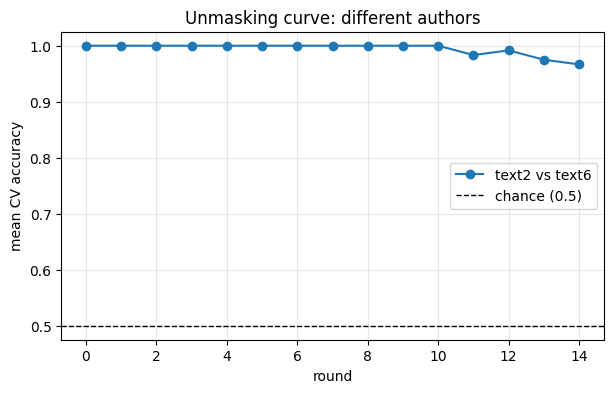

In [42]:
plt.figure(figsize=(7, 4))
plt.plot(res_diff.accuracies, marker="o", label="text2 vs text6")
plt.axhline(0.5, color="black", linewidth=1, linestyle="--", label="chance (0.5)")
plt.title("Unmasking curve: different authors")
plt.xlabel("round")
plt.ylabel("mean CV accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### What features get removed?

Because we use a *linear* classifier, each feature has a weight.
Large positive weights push predictions towards “right text”, large negative weights towards “left text”.

Below we show a few removed n-grams from the first round.


In [43]:
first_removed = res_diff.removed_feature_indices[0]
print("Removed features in round 0 (showing up to 20):")
for idx in first_removed[:20]:
    print(repr(vocab_diff[int(idx)]))


Removed features in round 0 (showing up to 20):
' th'
' : '
' . '
'the'
' ! '
'er '
'ed '
' to'
" ' "
'R :'


## Demo B: Same author control (split `text1` into two halves)

As a rough control, we split a single book into two halves and pretend they are “two authors”.
We expect fewer stable stylistic differences, so accuracy should move towards chance **faster** than in Demo A.

(Reality check: topic shifts and narrative structure can still introduce differences even within one book.)


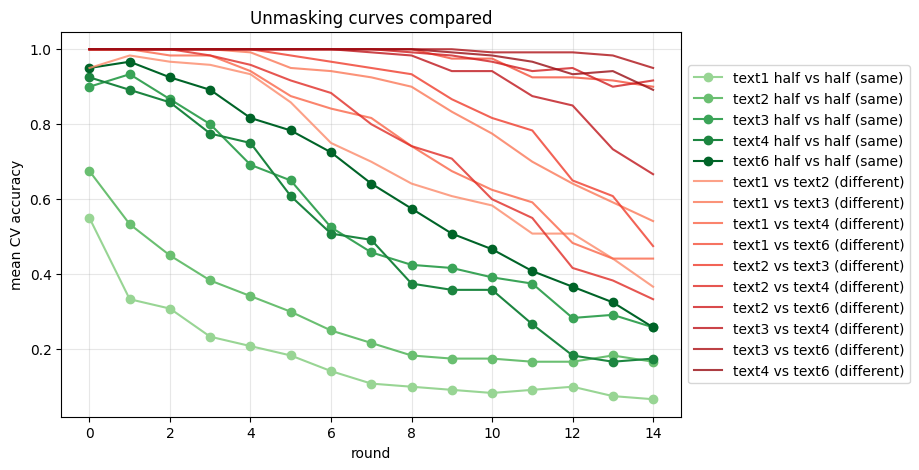

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

texts = {
    "text1": text1.tokens,
    "text2": text2.tokens,
    "text3": text3.tokens,
    "text4": text4.tokens,
    "text6": text6.tokens,
}

params = dict(
    ngram_n=3,
    chunk_size=500,
    bootstrap=True,
    n_chunks=60,
    top_n=250,
    rounds=15,
    n_delete=5,
    cv_folds=5,
    random_state=0,
)

plt.figure(figsize=(8, 5))

# colormaps
same_cmap = plt.cm.Greens
diff_cmap = plt.cm.Reds

# SAME AUTHOR (green shades)
same_names = list(texts.keys())
same_colors = same_cmap(np.linspace(0.4, 0.9, len(same_names)))

for (name, tokens), color in zip(texts.items(), same_colors):
    mid = len(tokens) // 2
    left, right = tokens[:mid], tokens[mid:]
    res, _ = unmask_text_pair(left, right, **params)
    plt.plot(res.accuracies, marker="o", color=color,
             label=f"{name} half vs half (same)")

# DIFFERENT AUTHORS (red shades)
pairs = list(combinations(texts.items(), 2))
diff_colors = diff_cmap(np.linspace(0.4, 0.9, len(pairs)))

for ((name_a, tokens_a), (name_b, tokens_b)), color in zip(pairs, diff_colors):
    res, _ = unmask_text_pair(tokens_a, tokens_b, **params)
    plt.plot(res.accuracies, alpha=0.8, color=color,
             label=f"{name_a} vs {name_b} (different)")

plt.title("Unmasking curves compared")
plt.xlabel("round")
plt.ylabel("mean CV accuracy")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.show()

## Interpreting unmasking curves

**How to read the plot**
<details>
<summary>Click to expand </summary>
- The y-axis is classification accuracy between left vs right chunks.
- The x-axis is the number of “unmasking rounds” (feature deletions).
</details>

**Typical patterns**
<details>
<summary>Click to expand </summary>

- Slow decay: many independent signals separate the texts → often consistent with different authors or different registers.
- Fast decay: only a small number of features mattered → often consistent with the same author/style.
</details>

**What unmasking does NOT guarantee**
- It is *not* a proof of authorship.
- Topic, genre, time period, and editing can dominate stylistic signals.
- Curves depend heavily on: chunk size, feature choice (char vs word n-grams), top_n, folds, and text length.

Treat unmasking as an **exploratory diagnostic**: it helps you *understand* what makes two texts separable.


## Try it yourself (experiments)

1. Change `ngram_n` from 3 to 4. What happens?
2. Set `bootstrap=False` and compare curves.
3. Compare `text2` vs `text3` (Austen vs Bible).
4. Increase `n_delete`. Does the curve drop faster? Why?
5. Decrease `chunk_size`. Do results get noisier?


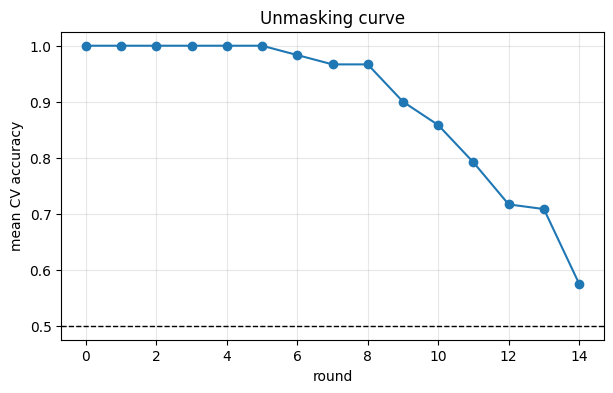

In [45]:
# Playground cell: edit parameters and rerun
res, vocab = unmask_text_pair(
    text2.tokens,
    text3.tokens,
    ngram_n=3,
    chunk_size=500,
    bootstrap=True,
    n_chunks=60,
    top_n=250,
    rounds=15,
    n_delete=5,
    cv_folds=5,
    random_state=0,
)

plt.figure(figsize=(7, 4))
plt.plot(res.accuracies, marker="o")
plt.axhline(0.5, color="black", linewidth=1, linestyle="--")
plt.title("Unmasking curve")
plt.xlabel("round")
plt.ylabel("mean CV accuracy")
plt.grid(True, alpha=0.3)
plt.show()
